In [1]:
import json
import os

# Percorso del file fornito
file_path = '/home/giacomo/LLMs_For_Green_Code_Refactoring/data/processed/green/swe_perf_green_k3.json'

# Verifica esistenza file
if not os.path.exists(file_path):
    print(f"ERRORE: Il file non esiste al percorso: {file_path}")
else:
    with open(file_path, 'r') as f:
        data = json.load(f)

    print(f"--- ANALISI STRUTTURALE ROOT ---")
    print(f"Tipo di dato Root: {type(data)}")
    
    if isinstance(data, dict):
        print(f"\nChiavi trovate nella Root: {list(data.keys())}")
        
        # Esploriamo i valori dei metadati (escludendo la lista delle istanze per ora)
        print("\n--- METADATI GLOBALI ---")
        for key, value in data.items():
            if isinstance(value, list):
                # Se è una lista, stampiamo solo la lunghezza per capire dove sono i dati
                print(f"Chiave '{key}': [LISTA] con {len(value)} elementi")
            else:
                # Se è un valore scalare, lo stampiamo
                print(f"Chiave '{key}': {value}")
    elif isinstance(data, list):
        print(f"Il dataset è una lista diretta di {len(data)} elementi.")

--- ANALISI STRUTTURALE ROOT ---
Tipo di dato Root: <class 'dict'>

Chiavi trovate nella Root: ['metadata', 'instances']

--- METADATI GLOBALI ---
Chiave 'metadata': {'name': 'SWE-Perf Green Extended (k=3)', 'description': 'Green software metrics with 3 measurement repetitions', 'repetitions': 3, 'instance_count': 125, 'total_tests': 735, 'green_metrics': ['cpu_energy_joules', 'gpu_energy_joules', 'total_energy_joules', 'power_watts', 'carbon_grams', 'energy_efficiency'], 'efficiency_metrics': ['duration_seconds', 'cpu_usage_mean_percent', 'cpu_usage_peak_percent', 'ram_usage_mean_mb', 'ram_usage_peak_mb', 'gpu_temperature_mean_celsius', 'gpu_temperature_peak_celsius'], 'aggregations': ['mean', 'std', 'min', 'max'], 'creation_date': '2026-01-04T19:26:58.668507'}
Chiave 'instances': [LISTA] con 125 elementi


In [2]:
# Assumiamo che la variabile 'data' sia già caricata dal passo precedente.
# Se hai chiuso la sessione, ricarica il file json prima di eseguire questo.

if 'instances' in data and len(data['instances']) > 0:
    first_instance = data['instances'][0]
    
    print("--- ANALISI PRIMA ISTANZA ---")
    print(f"Keys nell'oggetto istanza: {list(first_instance.keys())}")
    
    # Dettagli identificativi
    print(f"\nID Istanza: {first_instance.get('instance_id')}")
    print(f"Repository: {first_instance.get('repo')}")
    
    # Verifica presenza Patch (il codice)
    patch_content = first_instance.get('patch', '')
    print(f"Lunghezza della Patch (caratteri): {len(patch_content)}")
    
    # Analisi della struttura delle metriche (il cuore del dataset)
    green_metrics = first_instance.get('green_metrics', {})
    print(f"\nNumero di test misurati in questa istanza: {len(green_metrics)}")
    
    if len(green_metrics) > 0:
        # Prendiamo il primo test disponibile
        test_name = list(green_metrics.keys())[0]
        test_data = green_metrics[test_name]
        
        print(f"\n--- STRUTTURA METRICHE PER IL TEST: '{test_name}' ---")
        print(f"Stati disponibili (dovrebbe essere base/head): {list(test_data.keys())}")
        
        # Analizziamo le metriche dentro 'head' (post-ottimizzazione)
        if 'head' in test_data:
            metrics_head = test_data['head']
            print(f"Numero di metriche registrate per 'head': {len(metrics_head)}")
            
            # Stampiamo le prime 5 chiavi per verificare le aggregazioni (mean, std, ecc.)
            print("Esempio prime 5 metriche:")
            for m in list(metrics_head.keys())[:5]:
                print(f"  - {m}: {metrics_head[m]}")
else:
    print("Errore: Nessuna istanza trovata nel dataset.")

--- ANALISI PRIMA ISTANZA ---
Keys nell'oggetto istanza: ['repo', 'instance_id', 'patch', 'test_patch', 'base_commit', 'head_commit', 'created_at', 'version', 'efficiency_test', 'patch_functions', 'test_functions', 'human_performance', 'green_metrics', '_green_metadata']

ID Istanza: astropy__astropy-16065
Repository: astropy/astropy
Lunghezza della Patch (caratteri): 1039

Numero di test misurati in questa istanza: 2

--- STRUTTURA METRICHE PER IL TEST: 'astropy/timeseries/periodograms/lombscargle/tests/test_statistics.py::test_distribution[False-True-log]' ---
Stati disponibili (dovrebbe essere base/head): ['base', 'head']
Numero di metriche registrate per 'head': 52
Esempio prime 5 metriche:
  - cpu_energy_joules_mean: 35.136789958303176
  - cpu_energy_joules_std: 13.131074371613133
  - cpu_energy_joules_min: 26.935836791992188
  - cpu_energy_joules_max: 50.28187561221421
  - gpu_energy_joules_mean: 23.03588393609919


In [3]:
import pandas as pd

# Lista per raccogliere i dati appiattiti
flat_data = []

# Iteriamo su tutte le istanze
if 'instances' in data:
    for instance in data['instances']:
        inst_id = instance.get('instance_id')
        repo = instance.get('repo')
        
        # Iteriamo su tutti i test dentro l'istanza
        green_metrics = instance.get('green_metrics', {})
        for test_name, measurements in green_metrics.items():
            
            # Prepariamo la riga base
            row = {
                'instance_id': inst_id,
                'repo': repo,
                'test_name': test_name
            }
            
            # Estraiamo le metriche MEAN per Base e Head
            # Ci concentriamo sulle medie per la visione d'insieme, 
            # ma il dataset ha anche min/max/std
            for state in ['base', 'head']:
                if state in measurements:
                    metrics = measurements[state]
                    # Estraiamo alcune metriche chiave (CPU Energy, Total Energy, Duration)
                    row[f'{state}_cpu_energy_mean'] = metrics.get('cpu_energy_joules_mean')
                    row[f'{state}_gpu_energy_mean'] = metrics.get('gpu_energy_joules_mean')
                    row[f'{state}_total_energy_mean'] = metrics.get('total_energy_joules_mean')
                    row[f'{state}_duration_mean'] = metrics.get('duration_seconds_mean')
            
            flat_data.append(row)

# Creazione DataFrame
df = pd.DataFrame(flat_data)

print("--- DATAFRAME CREATO ---")
print(f"Dimensioni del DataFrame: {df.shape}")
print(f"Colonne presenti: {list(df.columns)}")

print("\n--- ESEMPIO PRIME 3 RIGHE ---")
print(df.head(3).to_string()) # to_string per evitare troncamenti brutali

print("\n--- STATISTICHE DESCRITTIVE (Solo colonne numeriche) ---")
# Descriviamo solo alcune colonne chiave per vedere i range di valori
cols_to_check = ['base_cpu_energy_mean', 'base_total_energy_mean', 'base_duration_mean']
print(df[cols_to_check].describe())

--- DATAFRAME CREATO ---
Dimensioni del DataFrame: (735, 11)
Colonne presenti: ['instance_id', 'repo', 'test_name', 'base_cpu_energy_mean', 'base_gpu_energy_mean', 'base_total_energy_mean', 'base_duration_mean', 'head_cpu_energy_mean', 'head_gpu_energy_mean', 'head_total_energy_mean', 'head_duration_mean']

--- ESEMPIO PRIME 3 RIGHE ---
              instance_id             repo                                                                                                                   test_name  base_cpu_energy_mean  base_gpu_energy_mean  base_total_energy_mean  base_duration_mean  head_cpu_energy_mean  head_gpu_energy_mean  head_total_energy_mean  head_duration_mean
0  astropy__astropy-16065  astropy/astropy                     astropy/timeseries/periodograms/lombscargle/tests/test_statistics.py::test_distribution[False-True-log]             35.368189             23.176230               58.544420            1.422722             35.136790             23.035884               58.17

In [4]:
# 1. Analisi della composizione per Repository
repo_counts = df['repo'].value_counts()

print("--- DISTRIBUZIONE TEST PER REPOSITORY ---")
print(repo_counts)

# 2. Calcolo dell'Impatto (Variazione Percentuale)
# Formula: (Base - Head) / Base * 100
# Positivo = Risparmio energetico (Miglioramento)
# Negativo = Regressione (Peggioramento)
df['cpu_savings_pct'] = ((df['base_cpu_energy_mean'] - df['head_cpu_energy_mean']) / df['base_cpu_energy_mean']) * 100
df['total_energy_savings_pct'] = ((df['base_total_energy_mean'] - df['head_total_energy_mean']) / df['base_total_energy_mean']) * 100

print("\n--- STATISTICHE SUI RISPARMI OTTENUTI (CPU Energy) ---")
print(df['cpu_savings_pct'].describe())

# 3. Vediamo alcuni casi estremi (Grandi risparmi vs Regressioni)
print("\n--- TOP 3 MIGLIORAMENTI (RISPARMIO CPU) ---")
print(df.nlargest(3, 'cpu_savings_pct')[['repo', 'test_name', 'cpu_savings_pct', 'base_cpu_energy_mean', 'head_cpu_energy_mean']].to_string(index=False))

print("\n--- TOP 3 REGRESSIONI (PEGGGIORAMENTI CPU) ---")
print(df.nsmallest(3, 'cpu_savings_pct')[['repo', 'test_name', 'cpu_savings_pct', 'base_cpu_energy_mean', 'head_cpu_energy_mean']].to_string(index=False))

--- DISTRIBUZIONE TEST PER REPOSITORY ---
pydata/xarray                396
scikit-learn/scikit-learn    212
sympy/sympy                   68
astropy/astropy               19
matplotlib/matplotlib         13
pylint-dev/pylint             10
mwaskom/seaborn                8
sphinx-doc/sphinx              8
psf/requests                   1
Name: repo, dtype: int64

--- STATISTICHE SUI RISPARMI OTTENUTI (CPU Energy) ---
count    735.000000
mean       1.035062
std        8.710095
min      -55.700507
25%       -2.004074
50%       -0.097398
75%        2.010124
max       54.508667
Name: cpu_savings_pct, dtype: float64

--- TOP 3 MIGLIORAMENTI (RISPARMIO CPU) ---
                     repo                                                                        test_name  cpu_savings_pct  base_cpu_energy_mean  head_cpu_energy_mean
scikit-learn/scikit-learn         sklearn/ensemble/tests/test_iforest.py::test_iforest_parallel_regression        54.508667             81.125509             36.905075
s

In [5]:
# Calcoliamo anche il risparmio di tempo e di potenza (Watts)
df['duration_savings_pct'] = ((df['base_duration_mean'] - df['head_duration_mean']) / df['base_duration_mean']) * 100

# Per la potenza (Watts), dobbiamo vedere se il profilo di consumo è cambiato
# Nota: power_watts_mean potrebbe non essere stato estratto nel passo precedente, 
# ma è presente nel dataset originale secondo la struttura.
# Se non l'abbiamo estratto prima, lo facciamo al volo ora ricaricando solo quel pezzo se necessario,
# ma per ora lavoriamo con quello che abbiamo: Duration vs Energy.

# Calcolo della Correlazione di Pearson e Spearman
# Pearson = relazione lineare
# Spearman = relazione monotona (più robusta agli outliers)

correlation_pearson = df[['duration_savings_pct', 'cpu_savings_pct', 'total_energy_savings_pct']].corr(method='pearson')
correlation_spearman = df[['duration_savings_pct', 'cpu_savings_pct', 'total_energy_savings_pct']].corr(method='spearman')

print("--- MATRICE DI CORRELAZIONE (PEARSON) ---")
print("Quanto sono lineari le relazioni?")
print(correlation_pearson)

print("\n--- MATRICE DI CORRELAZIONE (SPEARMAN) ---")
print("Quanto vanno nella stessa direzione (anche non linearmente)?")
print(correlation_spearman)

# Analisi dei casi divergenti:
# Cerchiamo casi dove il Tempo è migliorato (> 1%), ma l'Energia è peggiorata (< -1%)
# Questi sono i casi dove "Più veloce != Più Green"
divergent_cases = df[
    (df['duration_savings_pct'] > 1.0) & 
    (df['cpu_savings_pct'] < -1.0)
]

print(f"\n--- CASI DIVERGENTI (PIÙ VELOCE MA MENO GREEN) ---")
print(f"Numero di casi trovati: {len(divergent_cases)}")

if len(divergent_cases) > 0:
    print("\nEsempio Top 5 casi divergenti (ordinati per peggioramento energetico):")
    print(divergent_cases[['repo', 'test_name', 'duration_savings_pct', 'cpu_savings_pct']].sort_values('cpu_savings_pct').head(5).to_string(index=False))

--- MATRICE DI CORRELAZIONE (PEARSON) ---
Quanto sono lineari le relazioni?
                          duration_savings_pct  cpu_savings_pct  \
duration_savings_pct                  1.000000        -0.037755   
cpu_savings_pct                      -0.037755         1.000000   
total_energy_savings_pct              0.557133         0.779377   

                          total_energy_savings_pct  
duration_savings_pct                      0.557133  
cpu_savings_pct                           0.779377  
total_energy_savings_pct                  1.000000  

--- MATRICE DI CORRELAZIONE (SPEARMAN) ---
Quanto vanno nella stessa direzione (anche non linearmente)?
                          duration_savings_pct  cpu_savings_pct  \
duration_savings_pct                  1.000000        -0.253870   
cpu_savings_pct                      -0.253870         1.000000   
total_energy_savings_pct              0.570823         0.430122   

                          total_energy_savings_pct  
duration_savings

In [6]:
# 1. Calcolo della Potenza Media Derivata (Watts = Joules / Seconds)
# Questo ci dice quanto "intensamente" lavora la macchina
df['base_cpu_power_watts'] = df['base_cpu_energy_mean'] / df['base_duration_mean']
df['head_cpu_power_watts'] = df['head_cpu_energy_mean'] / df['head_duration_mean']

# Calcoliamo l'aumento di potenza in %
df['power_increase_pct'] = ((df['head_cpu_power_watts'] - df['base_cpu_power_watts']) / df['base_cpu_power_watts']) * 100

# 2. Categorizzazione dei Test ("Quadrant Analysis")
def categorize_test(row):
    # Soglia dell'1% per considerare il cambiamento significativo (per evitare rumore statistico)
    time_saved = row['duration_savings_pct'] > 1.0
    energy_saved = row['cpu_savings_pct'] > 1.0
    time_worse = row['duration_savings_pct'] < -1.0
    energy_worse = row['cpu_savings_pct'] < -1.0
    
    if time_saved and energy_saved:
        return "WIN-WIN (Green & Fast)"
    elif time_saved and energy_worse:
        return "TRADE-OFF (Faster but Brown)"  # Il caso divergente critico
    elif time_worse and energy_saved:
        return "SLOWER BUT GREEN (Rare)"
    elif time_worse and energy_worse:
        return "LOSE-LOSE (Regression)"
    else:
        return "NEUTRAL/NOISE"

df['category'] = df.apply(categorize_test, axis=1)

# 3. Analisi Aggregata per Categoria
print("--- DISTRIBUZIONE DELLE CATEGORIE ---")
category_stats = df.groupby('category').agg({
    'test_name': 'count',
    'duration_savings_pct': 'mean',
    'cpu_savings_pct': 'mean',
    'power_increase_pct': 'mean'  # <-- Questo è il dato chiave
}).sort_values('test_name', ascending=False)

print(category_stats)

# 4. Focus sul "Trade-off": Quanto aumenta la potenza in questi casi?
trade_off_df = df[df['category'] == "TRADE-OFF (Faster but Brown)"]
print(f"\n--- FOCUS TRADE-OFF ({len(trade_off_df)} casi) ---")
print(f"Aumento medio di potenza (Watts): +{trade_off_df['power_increase_pct'].mean():.2f}%")
print("Esempi estremi di aumento potenza:")
print(trade_off_df.nlargest(5, 'power_increase_pct')[['repo', 'test_name', 'duration_savings_pct', 'cpu_savings_pct', 'power_increase_pct']].to_string(index=False))

--- DISTRIBUZIONE DELLE CATEGORIE ---
                              test_name  duration_savings_pct  \
category                                                        
NEUTRAL/NOISE                       334             -0.168574   
TRADE-OFF (Faster but Brown)        143              7.409451   
SLOWER BUT GREEN (Rare)             129             -9.881037   
WIN-WIN (Green & Fast)               69              8.296477   
LOSE-LOSE (Regression)               60             -5.134369   

                              cpu_savings_pct  power_increase_pct  
category                                                           
NEUTRAL/NOISE                        0.382998           -0.344486  
TRADE-OFF (Faster but Brown)        -4.281119           13.587426  
SLOWER BUT GREEN (Rare)              6.478343          -14.267064  
WIN-WIN (Green & Fast)              11.148732           -2.824025  
LOSE-LOSE (Regression)              -5.998656            0.904553  

--- FOCUS TRADE-OFF (143 casi

In [7]:
# Funzione per recuperare le metriche di risorsa dal dizionario originale 'data'
# (Poiché non le avevamo estratte nel primo passaggio)
def get_resource_metrics(row):
    # Cerca l'istanza corretta
    # Nota: Questo è un metodo iterativo semplice. In produzione useremmo un indice hashmap, 
    # ma per 735 righe va benissimo così.
    instance = next((i for i in data['instances'] if i['instance_id'] == row['instance_id']), None)
    if not instance: return pd.Series([None]*4)
    
    metrics = instance['green_metrics'].get(row['test_name'], {})
    
    # Valori di default
    b_cpu, h_cpu, b_ram, h_ram = 0, 0, 0, 0
    
    if 'base' in metrics:
        b_cpu = metrics['base'].get('cpu_usage_mean_percent_mean', 0)
        b_ram = metrics['base'].get('ram_usage_mean_mb_mean', 0)
    
    if 'head' in metrics:
        h_cpu = metrics['head'].get('cpu_usage_mean_percent_mean', 0)
        h_ram = metrics['head'].get('ram_usage_mean_mb_mean', 0)
        
    return pd.Series([b_cpu, h_cpu, b_ram, h_ram])

# 1. Arricchiamo il DataFrame
print("Estrazione metriche risorse (CPU% e RAM)...")
df[['base_cpu_load', 'head_cpu_load', 'base_ram_mb', 'head_ram_mb']] = df.apply(get_resource_metrics, axis=1)

# 2. Calcoliamo i Delta Assoluti
df['delta_cpu_load'] = df['head_cpu_load'] - df['base_cpu_load']
df['delta_ram_mb'] = df['head_ram_mb'] - df['base_ram_mb']

# 3. Analisi per Categoria: Chi usa più risorse?
print("\n--- PROFILO HARDWARE PER CATEGORIA ---")
resource_profile = df.groupby('category').agg({
    'test_name': 'count',
    'power_increase_pct': 'mean',     # Quanto aumenta i Watt
    'delta_cpu_load': 'mean',         # Quanto aumenta il carico CPU (%)
    'delta_ram_mb': 'mean'            # Quanto aumenta la RAM (MB)
}).sort_values('power_increase_pct', ascending=False)

print(resource_profile)

# 4. Focus Specifico: Correlazione tra aumento CPU% e peggioramento Energetico
# Filtriamo solo i casi dove il tempo è migliorato (Time Savings > 0) per isolare l'efficienza
time_optimized = df[df['duration_savings_pct'] > 0].copy()
corr_cpu_energy = time_optimized['delta_cpu_load'].corr(time_optimized['cpu_savings_pct'])

print(f"\n--- CORRELAZIONE (Nei test accelerati) ---")
print(f"Correlazione tra 'Aumento Carico CPU' e 'Risparmio Energetico': {corr_cpu_energy:.4f}")
print("(Se negativo: Più carichi la CPU, meno energia risparmi)")

# 5. Esempio lampante dal gruppo Trade-off
print("\n--- ESEMPIO ESTREMO: AUMENTO CARICO CPU ---")
print(df[df['category'] == "TRADE-OFF (Faster but Brown)"].nlargest(3, 'delta_cpu_load')[['repo', 'test_name', 'delta_cpu_load', 'power_increase_pct']].to_string(index=False))

Estrazione metriche risorse (CPU% e RAM)...

--- PROFILO HARDWARE PER CATEGORIA ---
                              test_name  power_increase_pct  delta_cpu_load  \
category                                                                      
TRADE-OFF (Faster but Brown)        143           13.587426        0.624501   
LOSE-LOSE (Regression)               60            0.904553       -0.312986   
NEUTRAL/NOISE                       334           -0.344486       -0.047442   
WIN-WIN (Green & Fast)               69           -2.824025        0.176607   
SLOWER BUT GREEN (Rare)             129          -14.267064       -0.675305   

                              delta_ram_mb  
category                                    
TRADE-OFF (Faster but Brown)    -15.126264  
LOSE-LOSE (Regression)           -2.558813  
NEUTRAL/NOISE                   -17.512441  
WIN-WIN (Green & Fast)          -18.379214  
SLOWER BUT GREEN (Rare)          -9.334999  

--- CORRELAZIONE (Nei test accelerati) ---
Cor

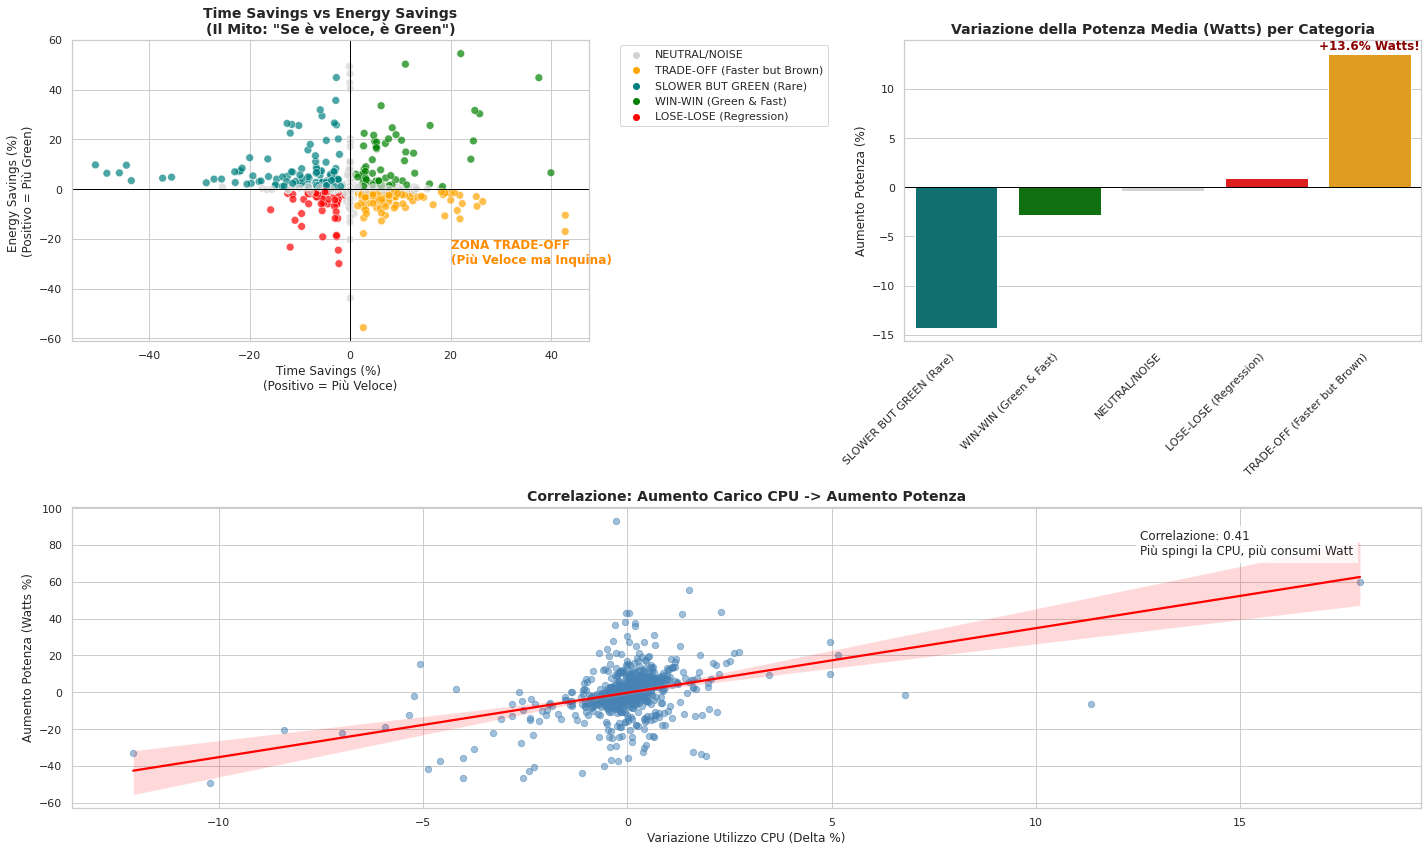

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Impostazioni estetiche
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 12))

# Definizione colori per le categorie
palette = {
    "WIN-WIN (Green & Fast)": "green",
    "TRADE-OFF (Faster but Brown)": "orange",
    "SLOWER BUT GREEN (Rare)": "teal",
    "LOSE-LOSE (Regression)": "red",
    "NEUTRAL/NOISE": "lightgrey"
}

# --- GRAFICO 1: IL QUADRANTE "TIME vs ENERGY" ---
plt.subplot(2, 2, 1)
sns.scatterplot(
    data=df, 
    x='duration_savings_pct', 
    y='cpu_savings_pct', 
    hue='category', 
    palette=palette,
    alpha=0.7,
    s=60
)

# Linee degli assi e area di Trade-off
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.title('Time Savings vs Energy Savings\n(Il Mito: "Se è veloce, è Green")', fontsize=14, fontweight='bold')
plt.xlabel('Time Savings (%) \n(Positivo = Più Veloce)', fontsize=12)
plt.ylabel('Energy Savings (%) \n(Positivo = Più Green)', fontsize=12)

# Evidenziamo l'area critica
plt.axvspan(xmin=1, xmax=df['duration_savings_pct'].max(), ymin=df['cpu_savings_pct'].min(), ymax=-1, color='orange', alpha=0.1)
plt.text(x=20, y=-30, s="ZONA TRADE-OFF\n(Più Veloce ma Inquina)", color='darkorange', fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


# --- GRAFICO 2: PERCHÉ SUCCEDE? L'AUMENTO DI POTENZA (WATTS) ---
plt.subplot(2, 2, 2)
# Ordiniamo per impatto potenza
order = ["SLOWER BUT GREEN (Rare)", "WIN-WIN (Green & Fast)", "NEUTRAL/NOISE", "LOSE-LOSE (Regression)", "TRADE-OFF (Faster but Brown)"]

sns.barplot(
    data=df, 
    x='category', 
    y='power_increase_pct', 
    palette=palette,
    order=order,
    ci=None  # <--- CORRETTO PER VERSIONI VECCHIE (Invece di errorbar=None)
)

plt.axhline(0, color='black', linewidth=1)
plt.title('Variazione della Potenza Media (Watts) per Categoria', fontsize=14, fontweight='bold')
plt.ylabel('Aumento Potenza (%)', fontsize=12)
plt.xlabel('')
plt.xticks(rotation=45, ha='right')

# Annotazione sulla barra Trade-off
plt.text(x=4, y=14, s="+13.6% Watts!", ha='center', fontweight='bold', color='darkred')


# --- GRAFICO 3: IL COLPEVOLE (CARICO CPU vs POTENZA) ---
plt.subplot(2, 1, 2)

# Filtriamo per rimuovere outlier estremi per rendere il grafico leggibile
subset = df[df['power_increase_pct'] < 100] 

sns.regplot(
    data=subset,
    x='delta_cpu_load',
    y='power_increase_pct',
    scatter_kws={'alpha':0.5, 's':40},
    line_kws={'color':'red'},
    color='steelblue'
)

plt.title('Correlazione: Aumento Carico CPU -> Aumento Potenza', fontsize=14, fontweight='bold')
plt.xlabel('Variazione Utilizzo CPU (Delta %)', fontsize=12)
plt.ylabel('Aumento Potenza (Watts %)', fontsize=12)

# Annotazioni
plt.text(x=subset['delta_cpu_load'].max()*0.7, y=subset['power_increase_pct'].max()*0.8, 
         s=f"Correlazione: {subset['delta_cpu_load'].corr(subset['power_increase_pct']):.2f}\nPiù spingi la CPU, più consumi Watt", 
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

--- LISTA DI SELEZIONE PER ESPERIMENTI LLM (5 PER CATEGORIA) ---

### CATEGORIA: TRADE-OFF
Instance ID                | Test Name
------------------------------------------------------------------------------------------------------------------------
pydata__xarray-8412       | pydata/xarray        |    42.8% |   -17.0% |   104.6% | xarray/tests/test_rolling.py::TestDataArrayRolling::test_rolling_reduce[numbagg-numpy-mean-3-1-True-1]
pydata__xarray-6834       | pydata/xarray        |    42.8% |   -10.5% |    93.2% | xarray/tests/test_plot.py::TestContour::test_verbose_facetgrid
pydata__xarray-9243       | pydata/xarray        |     2.6% |   -55.7% |    59.9% | xarray/tests/test_duck_array_ops.py::test_min_count[False-True-None-prod-True-int-1]
mwaskom__seaborn-2389     | mwaskom/seaborn      |    26.4% |    -5.0% |    42.6% | seaborn/tests/test_statistics.py::TestKDE::test_bw_method
sphinx-doc__sphinx-12615  | sphinx-doc/sphinx    |    14.6% |    -3.3% |    21.0% | tests/test_builders/

In [12]:
import json
import os

# CONFIGURAZIONE PERCORSI
input_path = '/home/giacomo/LLMs_For_Green_Code_Refactoring/data/processed/swe_perf_reduced.json'
output_path = '/home/giacomo/LLMs_For_Green_Code_Refactoring/data/processed/swe_perf_reduced_test.json'

# MAPPA DI SELEZIONE
# Associa l'Instance ID alla lista esatta dei test da mantenere.
# Ho unificato le istanze duplicate (es. scikit-learn-13186 che appariva in più categorie).
selection_map = {
    # --- TRADE-OFF (Faster but Brown) ---
    "pydata__xarray-8412": [
        "xarray/tests/test_rolling.py::TestDataArrayRolling::test_rolling_reduce[numbagg-numpy-mean-3-1-True-1]"
    ],
    "pydata__xarray-6834": [
        "xarray/tests/test_plot.py::TestContour::test_verbose_facetgrid"
    ],
    "pydata__xarray-9243": [
        "xarray/tests/test_duck_array_ops.py::test_min_count[False-True-None-prod-True-int-1]"
    ],
    "mwaskom__seaborn-2389": [
        "seaborn/tests/test_statistics.py::TestKDE::test_bw_method"
    ],
    "sphinx-doc__sphinx-12615": [
        "tests/test_builders/test_build_linkcheck.py::test_too_many_requests_retry_after_int_delay"
    ],

    # --- WIN-WIN (Green & Fast) ---
    "scikit-learn__scikit-learn-12543": [
        "sklearn/ensemble/tests/test_iforest.py::test_iforest_parallel_regression"
    ],
    "scikit-learn__scikit-learn-13186": [
        # Questa istanza è interessante: ha test sia Win-Win che Slower-Green
        "sklearn/compose/tests/test_target.py::test_transform_target_regressor_invertible", # Win-Win
        "sklearn/decomposition/tests/test_pca.py::test_pca_randomized_solver",             # Win-Win
        "sklearn/decomposition/tests/test_kernel_pca.py::test_nested_circles",             # Slower-Green
        "sklearn/linear_model/tests/test_coordinate_descent.py::test_lasso_cv_positive_constraint", # Slower-Green
        "sklearn/tests/test_naive_bayes.py::test_alpha"                                    # Slower-Green
    ],
    "sympy__sympy-26848": [
        "sympy/series/tests/test_limitseq.py::test_limit_seq",
        "sympy/series/tests/test_limitseq.py::test_issue_10382"
    ],

    # --- LOSE-LOSE (Regression) ---
    "scikit-learn__scikit-learn-13151": [
        "sklearn/tests/test_common.py::test_estimators[MLPRegressor-check_fit_idempotent]",
        "sklearn/gaussian_process/tests/test_gpr.py::test_sample_statistics[kernel0]"
    ],
    "pydata__xarray-9407": [
        # Anche questa ha test misti Lose-Lose e Slower-Green
        "xarray/tests/test_backends.py::TestNetCDF4ViaDaskData::test_roundtrip_mask_and_scale[dtype0-create_unsigned_false_masked_scaled_data-create_encoded_unsigned_false_masked_scaled_data]", # Lose-Lose
        "xarray/tests/test_rolling.py::TestDatasetRolling::test_rolling_reduce[numpy-mean-3-None-False-1]", # Lose-Lose
        "xarray/tests/test_rolling.py::TestDatasetRolling::test_rolling_wrapped_bottleneck[1-numbagg-numpy-z2-1-None-sum]" # Slower-Green
    ],
    "pydata__xarray-9451": [
        "xarray/tests/test_rolling.py::TestDatasetRolling::test_rolling_reduce[numpy-mean-2-3-False-1]"
    ],

    # --- SLOWER-GREEN (Rare) ---
    "pydata__xarray-7209": [
        "xarray/tests/test_rolling.py::TestDatasetRolling::test_rolling_reduce[numpy-max-3-1-False-2]"
    ]
}

def create_filtered_dataset():
    # 1. Caricamento dati originali (che contengono patch, metadati, ecc.)
    if not os.path.exists(input_path):
        print(f"Errore: File non trovato in {input_path}")
        return

    with open(input_path, 'r') as f:
        full_data = json.load(f)
    
    # swe_perf_green_k1.json ha la struttura {'instances': [...]}, mentre swe_perf_reduced è una lista [...]
    # Prendiamo la lista delle istanze
    source_instances = full_data.get('instances', [])
    
    final_dataset = []
    found_ids = set()

    print(f"Scansione di {len(source_instances)} istanze originali...")

    # 2. Filtraggio e Costruzione
    for inst in source_instances:
        i_id = inst.get('instance_id')
        
        if i_id in selection_map:
            # Creiamo una copia per non modificare i dati originali in memoria
            new_inst = inst.copy()
            
            # --- PASSAGGIO CHIAVE ---
            # Sovrascriviamo 'efficiency_test' per includere SOLO i test che abbiamo selezionato.
            # Questo obbligherà la pipeline di test a misurare solo ciò che ci interessa.
            target_tests = selection_map[i_id]
            new_inst['efficiency_test'] = target_tests
            
            # Puliamo anche le green_metrics per coerenza (tieni solo i test selezionati)
            if 'green_metrics' in new_inst:
                new_metrics = {k: v for k, v in new_inst['green_metrics'].items() if k in target_tests}
                new_inst['green_metrics'] = new_metrics
            
            # Rimuoviamo il campo '_green_metadata' se non serve nel formato 'reduced', 
            # ma tenerlo non fa male. Lo teniamo per reference.
            
            final_dataset.append(new_inst)
            found_ids.add(i_id)

    # 3. Validazione
    print(f"\nIstanze trovate e processate: {len(final_dataset)}")
    missing = set(selection_map.keys()) - found_ids
    if missing:
        print(f"ATTENZIONE: Non ho trovato queste istanze nel dataset sorgente: {missing}")
    else:
        print("Successo: Tutte le istanze target sono state recuperate.")

    # 4. Salvataggio
    with open(output_path, 'w') as f:
        json.dump(final_dataset, f, indent=2)
    
    print(f"\nFile salvato con successo in:\n{output_path}")
    print("Formato: Lista JSON (compatibile con swe_perf_reduced.json)")

# Esecuzione
create_filtered_dataset()

AttributeError: 'list' object has no attribute 'get'

In [20]:
import json
import os

# CONFIGURAZIONE PERCORSI
input_path = '/home/giacomo/LLMs_For_Green_Code_Refactoring/data/processed/swe_perf_reduced.json'
output_path = '/home/giacomo/LLMs_For_Green_Code_Refactoring/data/processed/swe_perf_reduced_test.json'

# LISTA DELLE 12 ISTANZE TARGET (ID univoci)
# Queste sono le istanze che contengono i comportamenti Trade-off, Win-Win, ecc.
target_ids = {
    # --- TRADE-OFF ---
    "pydata__xarray-8412",
    "pydata__xarray-6834",
    "pydata__xarray-9243",
    "mwaskom__seaborn-2389",
    "sphinx-doc__sphinx-12615",
    
    # --- WIN-WIN ---
    "scikit-learn__scikit-learn-12543",
    "scikit-learn__scikit-learn-13186", # (Include anche casi Slower-Green)
    "sympy__sympy-26848",
    
    # --- LOSE-LOSE ---
    "scikit-learn__scikit-learn-13151",
    "pydata__xarray-9407",             # (Include anche casi Slower-Green)
    "pydata__xarray-9451",
    
    # --- SLOWER-GREEN ---
    "pydata__xarray-7209"
}

def create_full_test_dataset():
    if not os.path.exists(input_path):
        print(f"ERRORE: File non trovato: {input_path}")
        return

    # 1. Caricamento Dataset Completo
    with open(input_path, 'r') as f:
        instances = json.load(f)
    
    print(f"Dataset originale caricato: {len(instances)} istanze totali.")
    
    filtered_instances = []
    found_ids = set()

    # 2. Selezione Istanze (Senza modificare i test)
    for inst in instances:
        iid = inst.get('instance_id')
        
        if iid in target_ids:
            # Copiamo l'intera istanza così com'è, preservando TUTTI i campi
            # inclusi tutti gli elementi originali di 'efficiency_test'
            filtered_instances.append(inst)
            found_ids.add(iid)

    # 3. Verifica Integrità
    print(f"\nIstanze selezionate: {len(filtered_instances)}")
    
    # Controllo numero di test per istanza (giusto per conferma)
    print("\n--- Dettaglio Test Inclusi ---")
    for inst in filtered_instances:
        print(f"ID: {inst['instance_id']:<35} | Test presenti: {len(inst['efficiency_test'])}")

    missing = target_ids - found_ids
    if missing:
        print(f"\nATTENZIONE: Mancano {len(missing)} istanze:")
        print(missing)
    else:
        print("\nSuccesso: Tutte le 12 istanze target sono state recuperate con TUTTI i loro test.")

    # 4. Salvataggio
    with open(output_path, 'w') as f:
        json.dump(filtered_instances, f, indent=2)

    print(f"\nFile salvato in: {output_path}")

if __name__ == "__main__":
    create_full_test_dataset()

Dataset originale caricato: 131 istanze totali.

Istanze selezionate: 12

--- Dettaglio Test Inclusi ---
ID: mwaskom__seaborn-2389               | Test presenti: 2
ID: pydata__xarray-9451                 | Test presenti: 9
ID: pydata__xarray-9407                 | Test presenti: 9
ID: pydata__xarray-9243                 | Test presenti: 10
ID: pydata__xarray-8412                 | Test presenti: 1
ID: pydata__xarray-7209                 | Test presenti: 34
ID: pydata__xarray-6834                 | Test presenti: 1
ID: scikit-learn__scikit-learn-13186    | Test presenti: 9
ID: scikit-learn__scikit-learn-13151    | Test presenti: 4
ID: scikit-learn__scikit-learn-12543    | Test presenti: 8
ID: sphinx-doc__sphinx-12615            | Test presenti: 5
ID: sympy__sympy-26848                  | Test presenti: 6

Successo: Tutte le 12 istanze target sono state recuperate con TUTTI i loro test.

File salvato in: /home/giacomo/LLMs_For_Green_Code_Refactoring/data/processed/swe_perf_reduced_test.j